In [16]:
file_path = "outputs/"

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2, norm, cauchy

# Excercise 01.1: Testing Random Number Generator

The goal of this first exercise is to test the reliability of our random number generator. We begin by evaluating the mean and variance of the generated sequences to ensure they are compatible with the theoretical expectations of a uniform distribution. Finally, a Pearson's $\chi^2$ test is performed to rigorously verify the uniformity of the sampled data.

## The Data Blocking Method: Object-Oriented Approach

To compute the statistical uncertainties, the simulation relies on the **Data Blocking** method. To keep the C++ code modular, clean, and reusable across different observables (such as the mean and the variance), this logic has been encapsulated in a custom `DataBlocker` class.

### How it works:
1. **Initialization:** The object is instantiated by providing the block size $L$. It automatically initializes all internal sums and counters to zero.
2. **Feeding Data:** Inside the main simulation loop, each new measurement is simply passed to the class using the `add_measurement(value)` method. 
3. **Automatic Blocking:** The class internally keeps track of the data flow. As soon as $L$ measurements are collected, it automatically closes the block, recursively updates the progressive mean $\langle A \rangle$ and the squared mean $\langle A^2 \rangle$, and resets the internal block counter for the next batch.
4. **Extracting Results:** At the end of each block, the progressive estimation of the observable and its statistical uncertainty can be retrieved using the getter methods `get_mean()` and `get_error()`.

## Excercise 01.1.1: mean and its uncertainty

In [18]:
# Extract the data from the output files
throws, blocks, sum_prog, err_prog, var_prog, err_var_prog = np.loadtxt(file_path + "01_1_means_and_variances.dat", unpack=True)

First I plot the value of the mean as a function of the number of blocks: the plot shows that the mean approaches the expected value (in this case 0.5) for a large number of blocks. The bars represent the uncertainty on the current value of the mean.

The value of the mean is compatible with the expected value.

The plot shows the values of the mean minus the expected value, therefore the expected value of the quantity $\langle r \rangle- 0.5$ is zero. 

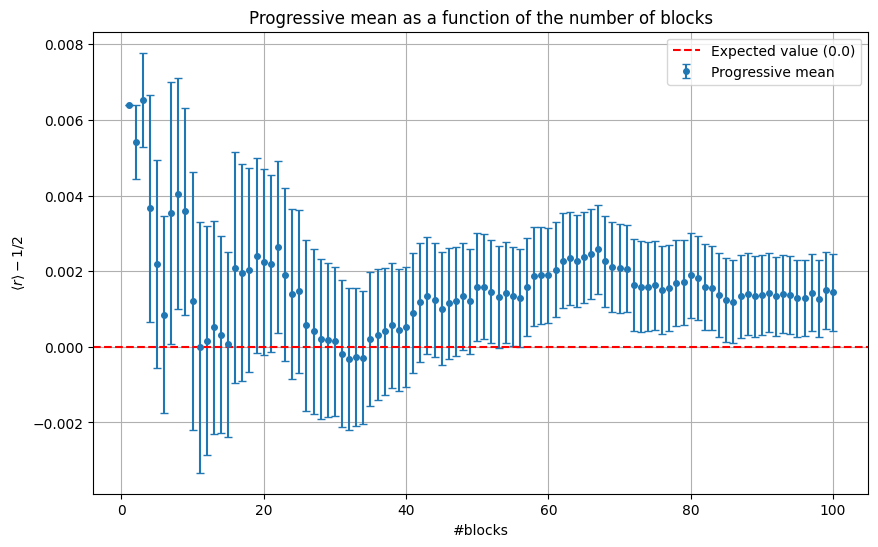

In [19]:
plt.figure(figsize=(10, 6))

plt.errorbar(blocks, sum_prog - 0.5, yerr=err_prog, label = 'Progressive mean', fmt='o', markersize=4, capsize=3)
plt.axhline(0, color='red', linestyle='--', label='Expected value (0.0)')
plt.xlabel('#blocks')
plt.ylabel(r'$\langle r\rangle-1/2$')
plt.title('Progressive mean as a function of the number of blocks')
plt.grid(True)
plt.legend()
plt.show()

Therefore the estimate for the mean is given by the last row of the file and is shown below. Note that this is compatible with the true value $0.5$ within 2 standard deviations.

In [20]:
mean_final_estimate = sum_prog[-1]
mean_final_error = err_prog[-1]
print(f"===== Final estimation of the mean: {mean_final_estimate:.4f} ± {mean_final_error:.4f} =====")

===== Final estimation of the mean: 0.5014 ± 0.0010 =====


## Excercise 01.1.2: variance and its uncertainty

Here I plot the value of the variance as a function of the number of throws: the plot shows that the variance approaches the expected value (in this case 1/12) for a large number of throws. The bars represent the uncertainty on the current value of the variance.

The value of the variance is compatible with the expected value.

The plot shows the values of the variance minus the expected value, therefore the expected value of the quantity $(<r>- 0.5)^2-1/12$ is zero.

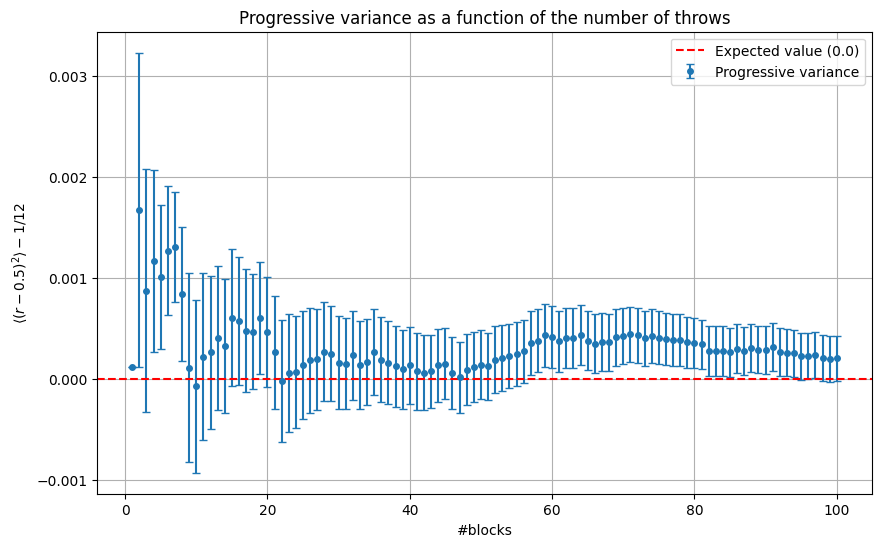

In [21]:
plt.figure(figsize=(10, 6))

plt.errorbar(blocks, var_prog - 1.0/12.0, yerr=err_var_prog, label = 'Progressive variance', fmt='o', markersize=4, capsize=3)
plt.axhline(0, color='red', linestyle='--', label='Expected value (0.0)')
plt.xlabel('#blocks')
plt.ylabel(r'$\langle (r-0.5)^2 \rangle - 1/12$')
plt.title('Progressive variance as a function of the number of throws')
plt.grid(True)
plt.legend()
plt.show()

Therefore the estimate for the variance is given by the last row of the file and is shown below. Note that this is compatible with the true value $1/12 \approx 0.08333$ within 1 standard deviations.

In [22]:
variance_final_estimate = var_prog[-1]
variance_final_error = err_var_prog[-1]
print(f"===== Final estimation of the variance: {variance_final_estimate:.5f} ± {variance_final_error:.5f} =====")

===== Final estimation of the variance: 0.08354 ± 0.00022 =====


## Excercise 01.1.3: compatibility of generated numbers with uniform distribution

In this section, we assess the uniformity of the generated numbers using Pearson's $\chi^2$ test. To this end, we computed $10^5$ independent values of $\chi^2$ and calculated their empirical mean, which, for a standard $\chi^2$ distribution, is expected to coincide with its number of degrees of freedom.

In the large sample limit, the test statistic:
$$\chi^2 = \sum_{i=1}^{n_{Bins}} \frac{\left( O_i - E_i \right)^2}{E_i}$$
approaches a $\chi^2$ distribution with $n_{Bins} - 1$ degrees of freedom. The subtraction of one degree of freedom stems from the fact that the total number of measurements is fixed, introducing a linear constraint among the bins. For these tests, we partitioned the interval $[0,1)$ into $n_{Bins} = 100$ sub-intervals, resulting in exactly $99$ degrees of freedom.

As shown below, the calculated mean of the $\chi^2$ values is closely compatible with the expected value of $99$. Furthermore, by superimposing the theoretical probability density function (PDF) of a $\chi^2_{99}$ distribution onto the histogram of our obtained values, we can observe an excellent agreement between the experimental data and the theoretical model.

In [23]:
# Import the chi-squared values obtained from the test of uniformity
chi_squared = np.loadtxt(file_path+"01_1_chi_squared.dat")

In [24]:
# Calculate the mean of the chi-squared values
mean_chi_squared=np.mean(chi_squared)
print(f"===== Mean of chi-squared values: {mean_chi_squared} =====")

===== Mean of chi-squared values: 98.9779504 =====


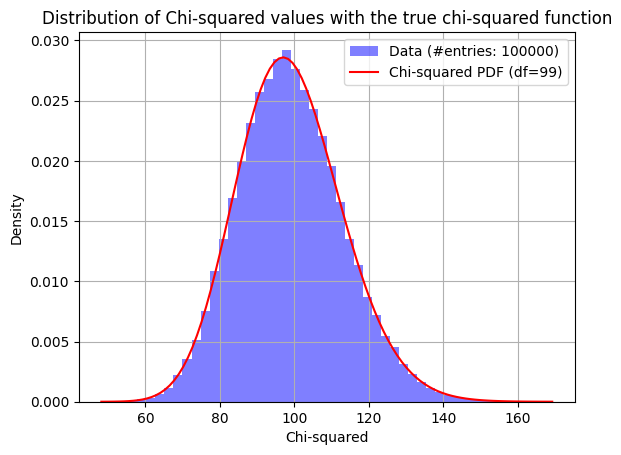

In [25]:
# Plot together the histogram and the chi-squared distribution
n_entries = len(chi_squared)
plt.hist(chi_squared, bins=50, density=True, alpha=0.5, color='blue', label=f'Data (#entries: {n_entries})')
x = np.linspace(min(chi_squared), max(chi_squared), 100)

theoretical_df = 100 - 1
plt.plot(x, chi2.pdf(x, df=mean_chi_squared), color='red', label=f'Chi-squared PDF (df={theoretical_df})')

plt.xlabel('Chi-squared')
plt.ylabel('Density')
plt.title('Distribution of Chi-squared values with the true chi-squared function')
plt.grid(True)
plt.legend()
plt.show()


# Excercise 01.2: Central Limit Theorem and Generalized Basins of Attraction

In this section, we investigate the Central Limit Theorem (CLT) and the concept of basins of attraction in the probability density function (PDF) space. To generate the required random variables, we employed the **method of the inversion of the cumulative distribution function (CDF)** to sample from a generic exponential distribution and a Cauchy-Lorentz distribution.

The classical CLT states that if $N$ independent random variables are identically distributed according to a PDF with a finite mean $\mu$ and a finite variance $\sigma^2$, then, in the limit $N \to \infty$, their sample mean $S_N = \frac{1}{N}\sum_{i=1}^N x_i$ follows a Gaussian distribution with mean $\mu$ and variance $\sigma^2/N$. The Gaussian distribution therefore acts as a universal basin of attraction.

However, the Cauchy-Lorentz distribution does not satisfy the hypotheses of the classical CLT because its variance is undefined (it diverges). Consequently, the sample mean of Lorentzian random variables is not guaranteed to converge to a Gaussian. Instead, the basin of attraction for the Lorentzian distribution is the Lorentzian distribution itself. It belongs to the broader class of **Lévy $\alpha$-stable distributions**, which are characterized by heavy power-law tails:
$$p(x) \underset{x \to \infty}{\approx} \frac{1}{|x|^{1+\alpha}}$$
where the Cauchy-Lorentz case corresponds exactly to the index $\alpha = 1$.

Stable distributions are invariant in shape under convolution. The *Lévy-Khintchine theorem* establishes that a probability density can be the limiting distribution of a sum of independent and identically distributed random variables only if it is stable. 

In the figures below, we present the empirical distributions of $S_N$ for uniform, exponential, and Lorentzian random variables, evaluated for increasing values of terms in the average ($N = 1, 2, 10, 100$). As expected, for $N=100$, the uniform and exponential sample means (having finite variances) are very well fitted by a Gaussian PDF. Conversely, the empirical sample mean of the Lorentzian variables is perfectly fitted by a Cauchy-Lorentz PDF.

In [26]:
# Import the data for the three different distributions
unif_1, unif_2, unif_10, unif_100 = np.loadtxt(file_path+"01_2_random_uniform.dat", unpack=True)
exp_1, exp_2, exp_10, exp_100 = np.loadtxt(file_path+"01_2_random_exponential.dat", unpack=True)
lor_1, lor_2, lor_10, lor_100 = np.loadtxt(file_path+"01_2_random_Lorentzian.dat", unpack=True)

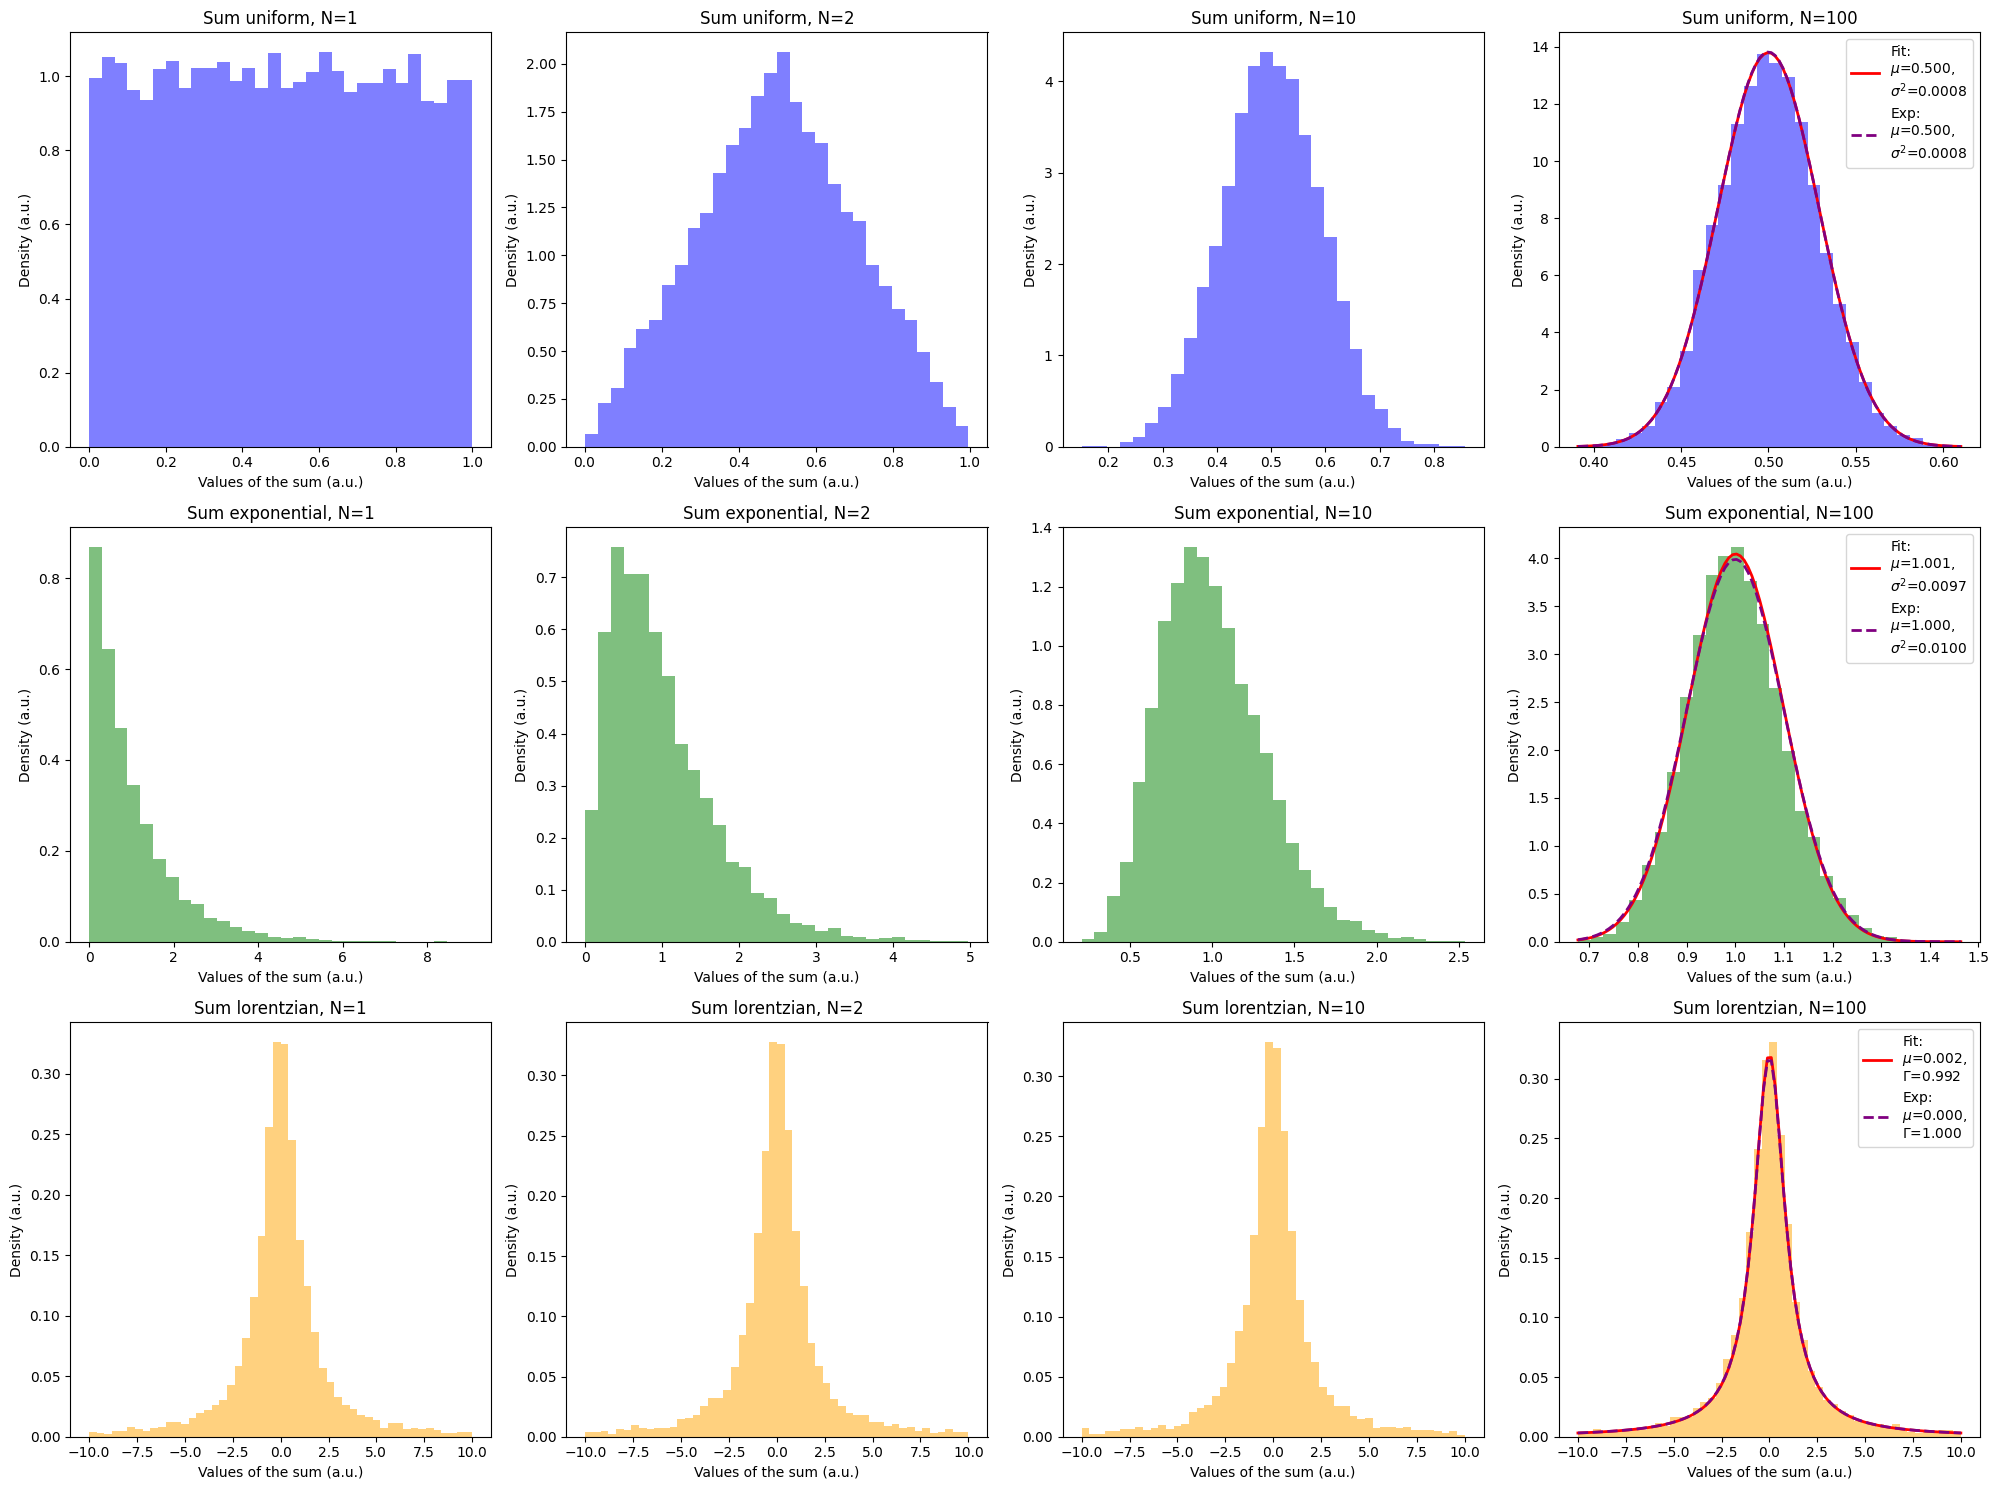

In [27]:
# Expected theoretical parameters

# Uniform distribution in [0,1)
mu_teo_unif = 0.5
var_teo_unif = 1.0 / 12.0

# Exponential distribution (lambda = 1)
mu_teo_exp = 1.0
var_teo_exp = 1.0

# Lorentzian (mu = 0, gamma = 1)
mu_teo_lor = 0.0
gamma_teo_lor = 1.0


# Number of terms in the sum
N_values = [1, 2, 10, 100]

uniforms = [unif_1, unif_2, unif_10, unif_100]
exponentials = [exp_1, exp_2, exp_10, exp_100]
lorentzians = [lor_1, lor_2, lor_10, lor_100]

# Plot
fig, axs = plt.subplots(3, 4, figsize=(20, 15))

for i in range(len(N_values)):
    current_N = N_values[i]
    
    # ---------------------------------------------------------
    # First row: Sum uniform
    # ---------------------------------------------------------
    axs[0, i].hist(uniforms[i], bins=30, density=True, alpha=0.5, color='blue')
    axs[0, i].set_title(f'Sum uniform, N={current_N}')
    axs[0, i].set_xlabel('Values of the sum (a.u.)')
    axs[0, i].set_ylabel('Density (a.u.)')
    
    if i == 3: # Gaussian fit and Expected PDF for N=100
        # Fit
        mu_fit, std_fit = norm.fit(uniforms[i])
        var_fit = std_fit**2
        x_unif = np.linspace(min(uniforms[i]), max(uniforms[i]), 100)
        p_fit = norm.pdf(x_unif, mu_fit, std_fit)
        
        # Expected (CLT)
        std_teo = np.sqrt(var_teo_unif / current_N)
        var_teo_S100 = var_teo_unif / current_N
        p_teo = norm.pdf(x_unif, mu_teo_unif, std_teo)
        
        # Plot
        axs[0, i].plot(x_unif, p_fit, 'r-', linewidth=2, label=f'Fit:\n$\mu$={mu_fit:.3f},\n$\sigma^2$={var_fit:.4f}')
        axs[0, i].plot(x_unif, p_teo, color='purple', linestyle='--', linewidth=2, label=f'Exp:\n$\mu$={mu_teo_unif:.3f},\n$\sigma^2$={var_teo_S100:.4f}')
        axs[0, i].legend(fontsize=10)

    
    # ---------------------------------------------------------
    # Second row: Sum exponential
    # ---------------------------------------------------------
    axs[1, i].hist(exponentials[i], bins=30, density=True, alpha=0.5, color='green')
    axs[1, i].set_title(f'Sum exponential, N={current_N}')
    axs[1, i].set_xlabel('Values of the sum (a.u.)')
    axs[1, i].set_ylabel('Density (a.u.)')
    
    if i == 3: # Gaussian fit and Expected PDF for N=100
        # Fit
        mu_fit, std_fit = norm.fit(exponentials[i])
        var_fit = std_fit**2
        x_exp = np.linspace(min(exponentials[i]), max(exponentials[i]), 100)
        p_fit = norm.pdf(x_exp, mu_fit, std_fit)
        
        # Expected (CLT)
        std_teo = np.sqrt(var_teo_exp / current_N)
        var_teo_S100 = var_teo_exp / current_N
        p_teo = norm.pdf(x_exp, mu_teo_exp, std_teo)
        
        # Plot
        axs[1, i].plot(x_exp, p_fit, 'r-', linewidth=2, label=f'Fit:\n$\mu$={mu_fit:.3f},\n$\sigma^2$={var_fit:.4f}')
        axs[1, i].plot(x_exp, p_teo, color='purple', linestyle='--', linewidth=2, label=f'Exp:\n$\mu$={mu_teo_exp:.3f},\n$\sigma^2$={var_teo_S100:.4f}')
        axs[1, i].legend(fontsize=10)
    
    # ---------------------------------------------------------
    # Third row: Sum lorentzian
    # ---------------------------------------------------------
    axs[2, i].hist(lorentzians[i], bins=50, range=(-10, 10), density=True, alpha=0.5, color='orange')
    axs[2, i].set_title(f'Sum lorentzian, N={current_N}')
    axs[2, i].set_xlabel('Values of the sum (a.u.)')
    axs[2, i].set_ylabel('Density (a.u.)')
    
    if i == 3: # Lorentzian fit and Expected PDF for N=100
        # Fit
        loc_fit, scale_fit = cauchy.fit(lorentzians[i])
        x_lor = np.linspace(-10, 10, 100)
        p_fit = cauchy.pdf(x_lor, loc_fit, scale_fit)
        
        # Expected (Lévy-Khintchine)
        p_teo = cauchy.pdf(x_lor, mu_teo_lor, gamma_teo_lor)
        
        # Plot
        axs[2, i].plot(x_lor, p_fit, 'r-', linewidth=2, label=f'Fit:\n$\mu$={loc_fit:.3f},\n$\Gamma$={scale_fit:.3f}')
        axs[2, i].plot(x_lor, p_teo, color='purple', linestyle='--', linewidth=2, label=f'Exp:\n$\mu$={mu_teo_lor:.3f},\n$\Gamma$={gamma_teo_lor:.3f}')
        axs[2, i].legend(fontsize=10)
        
plt.tight_layout()
plt.show()

### Uniform Distribution (Standard Dice)

For uniformly distributed variables in the interval $[0,1)$, the theoretical mean is $\mu_U = 0.5$ and the standard deviation is $\sigma_U = 1/\sqrt{12} \approx 0.289$. According to the Central Limit Theorem, the sample mean $S_N$ for $N = 100$ is expected to follow a Gaussian distribution with a mean $\mu_{S_{100}} = \mu_U = 0.5$ and a standard deviation $\sigma_{S_{100}} = \sigma_U/\sqrt{100} \approx 0.029$, and therefore $\sigma_{S_{100}}^2 \approx 0.0008$. 
This theoretical expectation is perfectly matched by the empirical Gaussian fit shown in the rightmost panel (the exact fitted parameters are reported in the legend).

### Exponential Distribution

The exponential variables were generated using a rate parameter $\lambda = 1.0$. Consequently, the exact theoretical mean of the distribution is $\mu_E = 1/\lambda = 1.0$, with a standard deviation $\sigma_E = 1/\lambda = 1.0$. 
As dictated by the CLT, the sample mean of $N=100$ exponential variables should converge to a Gaussian distribution centered at $\mu_{S_{100}} = 1.0$ with a standard deviation $\sigma_{S_{100}} = \sigma_E/\sqrt{100} = 0.1$, therefore $\sigma_{S_{100}}^2 \approx 0.01$. Once again, the parameters extracted from the Gaussian fit strictly confirm this asymptotic behavior.

### Cauchy-Lorentz Distribution

Since the Cauchy-Lorentz distribution lacks a finite variance, the classical CLT does not apply. However, because it is a strictly stable distribution (its shape is invariant under convolution), it acts as its own basin of attraction. 

This means that the sample mean of $N$ Lorentzian variables is still exactly a Lorentzian distribution. The location parameter $\mu$ and the scale parameter $\Gamma$ of the sample mean remain identical to those of the original single variables (in this simulation, $\mu = 0$ and $\Gamma = 1$).

# Excercise 01.3: Estimating $\pi$

### Buffon's Needle Experiment

For this exercise, we simulated Buffon's experiment for the stochastic estimation of $\pi$. The system parameters were set to $d=10$ (distance between the lines) and $l=5$ (length of the needle).

Crucially, to avoid any circular logic, we cannot use the true value of $\pi$ to uniformly sample the needle's orientation angle. To strictly bypass this, we implemented a 2D rejection sampling technique. The simulation logic is structured as follows:

```text
FOR EACH throw:
    - Extract a random number y_center in [0, d/2) 
      (Distance of the center of the needle from the closest line)
    
    - Extract the orientation of the needle:
        -> Extract 2 uniformly distributed variables, dx and dy, between 0 and 1
        -> Calculate the squared norm: norm_sq = dx^2 + dy^2
        -> IF norm_sq <= 1: 
               Accept the throw
           ELSE: 
               Reject and re-extract dx, dy
        (This uniformly samples the first quadrant of the unit circle, 
         ensuring the resulting angle is uniformly distributed)
        
    - Calculate the actual norm of the vector: r = sqrt(dx^2 + dy^2)
    - Compute the sine of the angle between the needle and the lines as: sin(theta) = dy / r
    
    - IF y_center <= (l / 2) * sin(theta):
        Count a crossing
```
Given $N_{throws}$ total throws and $N_{hit}$ crossings, the estimation of $\pi$ is given by

$$\hat{\pi} = \frac{2lN_{throws}}{dN_{hit}}$$

with $\hat{\pi}$ we meen the estimator for $\pi$.

The estimation of $\pi$ and its statistical uncertainty are evaluated for each block. The plot below displays the progressive estimation alongside its statistical error bars.

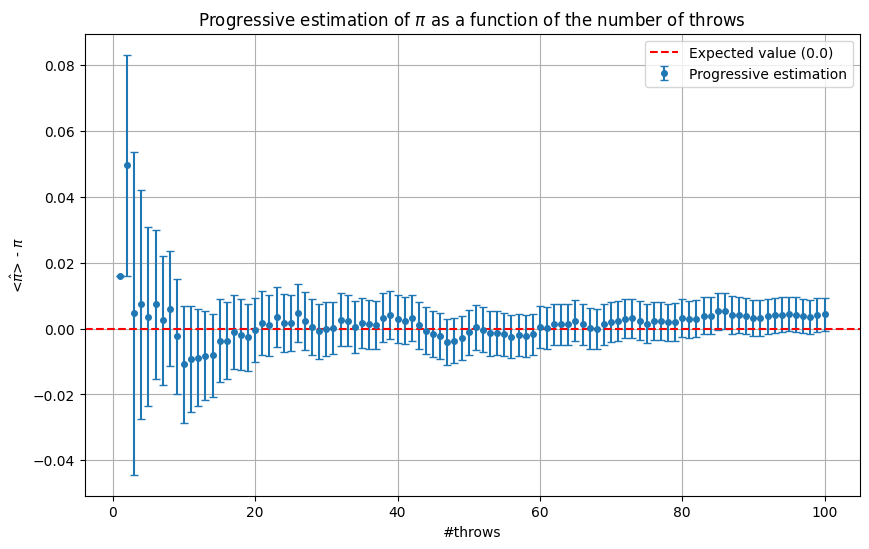

In [28]:
throws, blocks, pi_values, errs = np.loadtxt(file_path+"01_3_pi_estimate.dat", unpack=True)

plt.figure(figsize=(10, 6))

plt.errorbar(blocks, pi_values - np.pi, yerr=errs, label = 'Progressive estimation', fmt='o', markersize=4, capsize=3)
plt.axhline(0, color='red', linestyle='--', label='Expected value (0.0)')
plt.xlabel('#throws')
plt.ylabel('<$\hat{\pi}$> - $\pi$')
plt.title('Progressive estimation of $\pi$ as a function of the number of throws')
plt.grid(True)
plt.legend()
plt.show()

The plot above shows that the estimator value approacher $\pi$ as the number of throws increases, and is therefore a good estimator.

An estimation of $\pi$ that includes all the measurements is given by the last row in the files and is shown below.

In [29]:
pi_final_estimate = pi_values[-1]
pi_final_error = errs[-1]
print(f"===== Final estimation of pi: {pi_final_estimate:.6f} ± {pi_final_error:.6f} =====")

===== Final estimation of pi: 3.145880 ± 0.005038 =====
